# Predicting the Winning Football Team

- Sports betting is a 500 billion dollar market (Sydney Herald)

- Football is played by 250 million players in over 200 countries (most popular sport globally).
- The English Premier League is the most popular domestic team in the world.
- Design a predictive model capable of accurately predicting if the home team will win a football match? 


**Discription of Dataset**

**A prediction system was built to predict whether a home team will win it's match or not.**

Key to results data:
* Div = League Division
* Date = Match Date (dd/mm/yy)
* Time = Time of match kick-off
* HomeTeam = Home Team
* Away team = Away Team
* FTHG and HG = Full Time Home Team Goals
* FTAG and AG = Full-Time Away Team Goals
* FTR and Res = Full-Time Result (H=Home Win, D=Draw, A=Away Win)
* HTHG = Half Time Home Team Goals
* HTAG = Half Time Away Team Goals
* HTR = Half Time Result (H=Home Win, D=Draw, A=Away Win)

Match Statistics (where available)
* Attendance = Crowd Attendance
* Referee = Match Referee
* HS = Home Team Shots
* AS = Away Team Shots
* HST = Home Team Shots on Target
* AST = Away Team Shots on Target
* HHW = Home Team Hit Woodwork
* AHW = Away Team Hit Woodwork
* HC = Home Team Corners
* AC = Away Team Corners
* HF = Home Team Fouls Committed
* AF = Away Team Fouls Committed
* HFKC = Home Team Free Kicks Conceded
* AFKC = Away Team Free Kicks Conceded
* HO = Home Team Offsides
* AO = Away Team Offsides
* HY = Home Team Yellow Cards
* AY = Away Team Yellow Cards
*HR = Home Team Red Cards
AR = Away Team Red Cards
HBP = Home Team Bookings Points (10 = yellow, 25 = red)
ABP = Away Team Bookings Points (10 = yellow, 25 = red)

In [1]:
pip install pandas 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings("ignore")

In [3]:
old_df = pd.read_csv("matches.csv")

new_df = pd.read_csv("premier_league_2025.csv")

combined = pd.concat([old_df, new_df])

combined.to_csv("matches.csv", index=False)

### Importing the dataset

In [4]:
df = pd.read_csv("matches.csv")

df.head()

,Unnamed: 0,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,0.0,19/08/00,Charlton,Man City,4,0,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,1.0,19/08/00,Chelsea,West Ham,4,2,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
2,2.0,19/08/00,Coventry,Middlesbrough,1,3,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
3,3.0,19/08/00,Derby,Southampton,2,2,NH,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
4,4.0,19/08/00,Leeds,Everton,2,0,H,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


In [5]:
columns_req = [
    'Date',
    'HomeTeam',
    'AwayTeam',
    'FTHG',
    'FTAG',
    'FTR',
    'HTGS',
    'ATGS',
    'HTGD',
    'ATGD',
    'DiffPts'
]

df = df[columns_req]

df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGD,ATGD,DiffPts
0,19/08/00,Charlton,Man City,4,0,H,0,0,0.0,0.0,0.0
1,19/08/00,Chelsea,West Ham,4,2,H,0,0,0.0,0.0,0.0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,0,0,0.0,0.0,0.0
3,19/08/00,Derby,Southampton,2,2,NH,0,0,0.0,0.0,0.0
4,19/08/00,Leeds,Everton,2,0,H,0,0,0.0,0.0,0.0


**GOALS SCORED AND CONCEDED AT THE END OF MATCHWEEK, ARRANGED BY TEAMS AND MATCHWEEK**

In [6]:
# GOALS SCORED + GOALS CONCEDED STATS

def get_gss(df):

    # Home Team Goals Scored
    df["HTGS"] = (
        df.groupby("HomeTeam")["FTHG"]
        .cumsum()
        .shift(fill_value=0)
    )

    # Away Team Goals Scored
    df["ATGS"] = (
        df.groupby("AwayTeam")["FTAG"]
        .cumsum()
        .shift(fill_value=0)
    )

    # Home Team Goals Conceded
    df["HTGC"] = (
        df.groupby("HomeTeam")["FTAG"]
        .cumsum()
        .shift(fill_value=0)
    )

    # Away Team Goals Conceded
    df["ATGC"] = (
        df.groupby("AwayTeam")["FTHG"]
        .cumsum()
        .shift(fill_value=0)
    )

    return df


# APPLY FUNCTION
df = get_gss(df)

# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGD,ATGD,DiffPts,HTGC,ATGC
0,19/08/00,Charlton,Man City,4,0,H,0,0,0.0,0.0,0.0,0,0
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0.0,0.0,0.0,0,4
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,0.0,0.0,0.0,2,4
3,19/08/00,Derby,Southampton,2,2,NH,1,3,0.0,0.0,0.0,3,1
4,19/08/00,Leeds,Everton,2,0,H,2,2,0.0,0.0,0.0,2,2


**GET RESPECTIVE POINTS**

In [7]:
# TEAM POINTS CALCULATION

def calculate_points(df):

    # HOME TEAM POINTS
    home_points = []

    # AWAY TEAM POINTS
    away_points = []

    for result in df["FTR"]:

        if result == "H":
            home_points.append(3)
            away_points.append(0)

        elif result == "A":
            home_points.append(0)
            away_points.append(3)

        else:
            home_points.append(1)
            away_points.append(1)

    df["HomePoints"] = home_points
    df["AwayPoints"] = away_points

    # CUMULATIVE TEAM POINTS

    df["HTP"] = (
        df.groupby("HomeTeam")["HomePoints"]
        .cumsum()
        .shift(fill_value=0)
    )

    df["ATP"] = (
        df.groupby("AwayTeam")["AwayPoints"]
        .cumsum()
        .shift(fill_value=0)
    )

    return df


# APPLY FUNCTION
df = calculate_points(df)

# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGD,ATGD,DiffPts,HTGC,ATGC,HomePoints,AwayPoints,HTP,ATP
0,19/08/00,Charlton,Man City,4,0,H,0,0,0.0,0.0,0.0,0,0,3,0,0,0
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0.0,0.0,0.0,0,4,3,0,3,0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,0.0,0.0,0.0,2,4,1,1,3,0
3,19/08/00,Derby,Southampton,2,2,NH,1,3,0.0,0.0,0.0,3,1,1,1,1,1
4,19/08/00,Leeds,Everton,2,0,H,2,2,0.0,0.0,0.0,2,2,3,0,1,1


**GET TEAM FORM:**

In [8]:
# TEAM FORM FEATURES

def add_form_features(df):

    # Convert result into team-wise results

    home_form = []
    away_form = []

    for result in df["FTR"]:

        if result == "H":
            home_form.append("W")
            away_form.append("L")

        elif result == "A":
            home_form.append("L")
            away_form.append("W")

        else:
            home_form.append("D")
            away_form.append("D")

    df["HomeResult"] = home_form
    df["AwayResult"] = away_form

    # LAST 5 MATCH FORM

    for i in range(1, 6):

        df[f"HM{i}"] = (
            df.groupby("HomeTeam")["HomeResult"]
            .shift(i)
            .fillna("M")
        )

        df[f"AM{i}"] = (
            df.groupby("AwayTeam")["AwayResult"]
            .shift(i)
            .fillna("M")
        )

    return df


# APPLY FUNCTION
df = add_form_features(df)

# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGD,ATGD,...,HM1,AM1,HM2,AM2,HM3,AM3,HM4,AM4,HM5,AM5
0,19/08/00,Charlton,Man City,4,0,H,0,0,0.0,0.0,...,M,M,M,M,M,M,M,M,M,M
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0.0,0.0,...,M,M,M,M,M,M,M,M,M,M
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,0.0,0.0,...,M,M,M,M,M,M,M,M,M,M
3,19/08/00,Derby,Southampton,2,2,NH,1,3,0.0,0.0,...,M,M,M,M,M,M,M,M,M,M
4,19/08/00,Leeds,Everton,2,0,H,2,2,0.0,0.0,...,M,M,M,M,M,M,M,M,M,M


In [9]:
# REARRANGE COLUMNS

cols = [
    'Date',
    'HomeTeam',
    'AwayTeam',
    'FTHG',
    'FTAG',
    'FTR',
    'HTGS',
    'ATGS',
    'HTGC',
    'ATGC',
    'HTP',
    'ATP',
    'HM1',
    'HM2',
    'HM3',
    'HM4',
    'HM5',
    'AM1',
    'AM2',
    'AM3',
    'AM4',
    'AM5'
]

df = df[cols]

# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HM1,HM2,HM3,HM4,HM5,AM1,AM2,AM3,AM4,AM5
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,M,M,M,M,M,M,M,M,M,M
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0,4,...,M,M,M,M,M,M,M,M,M,M
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,2,4,...,M,M,M,M,M,M,M,M,M,M
3,19/08/00,Derby,Southampton,2,2,NH,1,3,3,1,...,M,M,M,M,M,M,M,M,M,M
4,19/08/00,Leeds,Everton,2,0,H,2,2,2,2,...,M,M,M,M,M,M,M,M,M,M


**Get MatchWeek:**

In [10]:
# MATCH WEEK

df = df.reset_index(drop=True)

# Every 10 matches = 1 match week
df["MW"] = (df.index // 10) + 1

# SHOW DATA
df.head()


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HM2,HM3,HM4,HM5,AM1,AM2,AM3,AM4,AM5,MW
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,M,M,M,M,M,M,M,M,M,1
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0,4,...,M,M,M,M,M,M,M,M,M,1
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,2,4,...,M,M,M,M,M,M,M,M,M,1
3,19/08/00,Derby,Southampton,2,2,NH,1,3,3,1,...,M,M,M,M,M,M,M,M,M,1
4,19/08/00,Leeds,Everton,2,0,H,2,2,2,2,...,M,M,M,M,M,M,M,M,M,1


**FINAL DATAFRAME**

In [11]:
# FORM POINTS

def get_form_points(form_string):

    points = 0

    for letter in form_string:

        if letter == "W":
            points += 3

        elif letter == "D":
            points += 1

    return points


# LAST 5 MATCH FORM STRING

df["HTFormPtsStr"] = (
    df["HM1"] +
    df["HM2"] +
    df["HM3"] +
    df["HM4"] +
    df["HM5"]
)

df["ATFormPtsStr"] = (
    df["AM1"] +
    df["AM2"] +
    df["AM3"] +
    df["AM4"] +
    df["AM5"]
)


# FORM POINTS

df["HTFormPts"] = df["HTFormPtsStr"].apply(get_form_points)

df["ATFormPts"] = df["ATFormPtsStr"].apply(get_form_points)


# WIN / LOSS STREAKS

df["HTWinStreak3"] = (
    df["HTFormPtsStr"]
    .apply(lambda x: 1 if x[-3:] == "WWW" else 0)
)

df["HTWinStreak5"] = (
    df["HTFormPtsStr"]
    .apply(lambda x: 1 if x == "WWWWW" else 0)
)

df["HTLossStreak3"] = (
    df["HTFormPtsStr"]
    .apply(lambda x: 1 if x[-3:] == "LLL" else 0)
)

df["HTLossStreak5"] = (
    df["HTFormPtsStr"]
    .apply(lambda x: 1 if x == "LLLLL" else 0)
)

df["ATWinStreak3"] = (
    df["ATFormPtsStr"]
    .apply(lambda x: 1 if x[-3:] == "WWW" else 0)
)

df["ATWinStreak5"] = (
    df["ATFormPtsStr"]
    .apply(lambda x: 1 if x == "WWWWW" else 0)
)

df["ATLossStreak3"] = (
    df["ATFormPtsStr"]
    .apply(lambda x: 1 if x[-3:] == "LLL" else 0)
)

df["ATLossStreak5"] = (
    df["ATFormPtsStr"]
    .apply(lambda x: 1 if x == "LLLLL" else 0)
)


# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTFormPts,ATFormPts,HTWinStreak3,HTWinStreak5,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0,4,...,0,0,0,0,0,0,0,0,0,0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,2,4,...,0,0,0,0,0,0,0,0,0,0
3,19/08/00,Derby,Southampton,2,2,NH,1,3,3,1,...,0,0,0,0,0,0,0,0,0,0
4,19/08/00,Leeds,Everton,2,0,H,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# GOAL DIFFERENCE

df["HTGD"] = df["HTGS"] - df["HTGC"]

df["ATGD"] = df["ATGS"] - df["ATGC"]


# POINT DIFFERENCE

df["DiffPts"] = df["HTP"] - df["ATP"]


# FORM POINT DIFFERENCE

df["DiffFormPts"] = (
    df["HTFormPts"] - df["ATFormPts"]
)


# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0,4,...,0,0,0,0,0,0,4,-4,3,0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,2,4,...,0,0,0,0,0,0,2,-2,3,0
3,19/08/00,Derby,Southampton,2,2,NH,1,3,3,1,...,0,0,0,0,0,0,-2,2,0,0
4,19/08/00,Leeds,Everton,2,0,H,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# SCALE FEATURES BY MATCH WEEK

cols = [
    'HTGD',
    'ATGD',
    'DiffPts',
    'DiffFormPts',
    'HTP',
    'ATP'
]

# Convert MW to float
df["MW"] = df["MW"].astype(float)

# Scale columns
for col in cols:

    df[col] = df[col] / df["MW"]


# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,19/08/00,Charlton,Man City,4,0,H,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0
1,19/08/00,Chelsea,West Ham,4,2,H,4,0,0,4,...,0,0,0,0,0,0,4.0,-4.0,3.0,0.0
2,19/08/00,Coventry,Middlesbrough,1,3,NH,4,2,2,4,...,0,0,0,0,0,0,2.0,-2.0,3.0,0.0
3,19/08/00,Derby,Southampton,2,2,NH,1,3,3,1,...,0,0,0,0,0,0,-2.0,2.0,0.0,0.0
4,19/08/00,Leeds,Everton,2,0,H,2,2,2,2,...,0,0,0,0,0,0,0.0,0.0,0.0,0.0


In [14]:
# CONVERT RESULT

# H  = Home Win
# NH = Not Home Win

df["FTR"] = df["FTR"].apply(
    lambda x: "H" if x == "H" else "NH"
)


# OPTIONAL:
# REMOVE EARLY MATCHES WITH LITTLE DATA

df = df[df["MW"] > 5]


# SHOW DATA
df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
50,16/09/00,Aston Villa,Bradford,2,0,H,9,5,4,4,...,0,0,0,0,0,0,0.833333,0.166667,1.166667,0.166667
51,16/09/00,Charlton,Tottenham,1,0,H,3,0,1,9,...,0,0,0,0,0,0,0.333333,-1.500000,0.666667,0.500000
52,16/09/00,Everton,Man United,1,3,NH,6,1,1,4,...,0,0,0,0,0,0,0.833333,-0.500000,1.000000,0.333333
53,16/09/00,Leeds,Ipswich,1,2,NH,6,6,5,4,...,0,0,0,0,0,0,0.166667,0.333333,0.333333,0.666667
54,16/09/00,Southampton,Newcastle,2,0,H,4,4,4,6,...,0,0,0,0,0,0,0.000000,-0.333333,0.666667,0.166667


In [15]:
# SAVE FINAL CLEANED DATASET

df.to_csv(
    "final_dataset.csv",
    index=False
)

print("final_dataset.csv saved successfully!")

final_dataset.csv saved successfully!


In [16]:
# SAVE TEST DATASET

df.to_csv(
    "test_set.csv",
    index=False
)

print("test_set.csv saved successfully!")

test_set.csv saved successfully!


In [17]:
#loading the final dataset
dataset = pd.read_csv('final_dataset.csv')

In [18]:
dataset.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
0,16/09/00,Aston Villa,Bradford,2,0,H,9,5,4,4,...,0,0,0,0,0,0,0.833333,0.166667,1.166667,0.166667
1,16/09/00,Charlton,Tottenham,1,0,H,3,0,1,9,...,0,0,0,0,0,0,0.333333,-1.500000,0.666667,0.500000
2,16/09/00,Everton,Man United,1,3,NH,6,1,1,4,...,0,0,0,0,0,0,0.833333,-0.500000,1.000000,0.333333
3,16/09/00,Leeds,Ipswich,1,2,NH,6,6,5,4,...,0,0,0,0,0,0,0.166667,0.333333,0.333333,0.666667
4,16/09/00,Southampton,Newcastle,2,0,H,4,4,4,6,...,0,0,0,0,0,0,0.000000,-0.333333,0.666667,0.166667


In [19]:
dataset.keys()

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTGS', 'ATGS',
       'HTGC', 'ATGC', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3', 'HM4', 'HM5', 'AM1',
       'AM2', 'AM3', 'AM4', 'AM5', 'MW', 'HTFormPtsStr', 'ATFormPtsStr',
       'HTFormPts', 'ATFormPts', 'HTWinStreak3', 'HTWinStreak5',
       'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3', 'ATWinStreak5',
       'ATLossStreak3', 'ATLossStreak5', 'HTGD', 'ATGD', 'DiffPts',
       'DiffFormPts'],
      dtype='object')

### Correlation Matrix for dataset

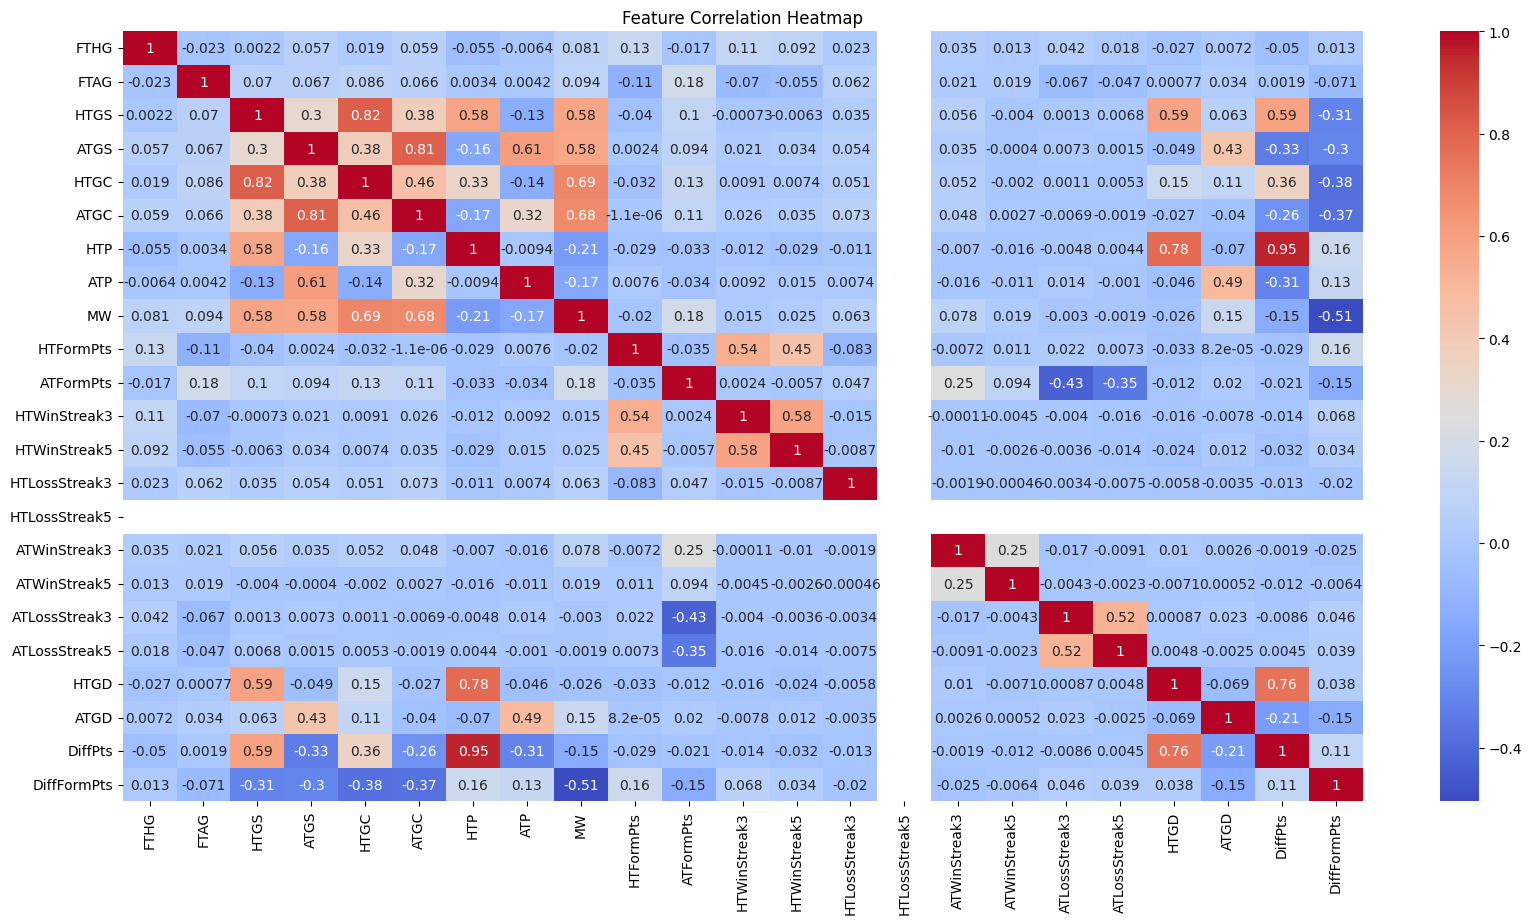

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# SELECT ONLY NUMERIC COLUMNS

numeric_df = df.select_dtypes(include=['number'])

# PLOT HEATMAP

plt.figure(figsize=(20,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

POSITIVE CORRELATION: If an increase in feature A leads to increase in feature B, then they are positively correlated. A value 1 means perfect positive correlation.

NEGATIVE CORRELATION: If an increase in feature A leads to decrease in feature B, then they are negatively correlated. A value -1 means perfect negative correlation.

Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as MultiColinearity as both of them contains almost the same information.

So do you think we should use both of them as one of them is redundant. While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.

In [21]:
# Remove few column
dataset2 = dataset.copy().drop(columns =['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG',
       'HTGS', 'ATGS', 'HTGC', 'ATGC',
       'HM4', 'HM5','AM4', 'AM5', 'MW', 'HTFormPtsStr',
       'ATFormPtsStr', 'HTFormPts', 'ATFormPts', 'HTWinStreak3',
       'HTWinStreak5', 'HTLossStreak3', 'HTLossStreak5', 'ATWinStreak3',
       'ATWinStreak5', 'ATLossStreak3', 'ATLossStreak5',
       'DiffPts'] )

In [22]:
dataset2.keys()

Index(['FTR', 'HTP', 'ATP', 'HM1', 'HM2', 'HM3', 'AM1', 'AM2', 'AM3', 'HTGD',
       'ATGD', 'DiffFormPts'],
      dtype='object')

In [23]:
dataset2.head(10)

,FTR,HTP,ATP,HM1,HM2,HM3,AM1,AM2,AM3,HTGD,ATGD,DiffFormPts
0,H,1.500000,0.333333,D,M,M,L,L,M,0.833333,0.166667,0.166667
1,H,0.666667,0.000000,D,W,M,L,D,M,0.333333,-1.500000,0.500000
2,NH,1.166667,0.166667,D,W,M,D,D,M,0.833333,-0.500000,0.333333
3,NH,0.833333,0.500000,D,W,M,L,L,M,0.166667,0.333333,0.666667
4,H,0.833333,0.166667,D,D,M,D,L,M,0.000000,-0.333333,0.166667
5,H,0.833333,0.166667,D,W,M,D,L,M,0.166667,-0.333333,0.500000
6,NH,1.166667,0.166667,D,W,M,D,D,M,0.333333,-0.333333,0.333333
7,NH,0.833333,0.500000,D,W,M,D,D,M,0.000000,0.500000,0.333333
8,NH,0.833333,0.500000,D,D,M,D,L,M,0.166667,0.333333,0.166667
9,NH,0.500000,0.333333,D,D,W,L,D,D,-0.166667,-0.333333,0.500000


In [24]:
#what is the win rate for the home team?

# Total number of matches.
n_matches = dataset2.shape[0]

# Calculate number of features. -1 because we are saving one as the target variable (win/lose/draw)
n_features = dataset2.shape[1] - 1

# Calculate matches won by home team.
n_homewins = len(dataset2[dataset2.FTR == 'H'])

# Calculate win rate for home team.
win_rate = (float(n_homewins) / (n_matches)) * 100

# Print the results
print("Total number of matches: {}".format(n_matches))
print ("Number of features: {}".format(n_features))
print( "Number of matches won by home team: {}".format(n_homewins))
print ("Win rate of home team: {:.2f}%".format(win_rate))

Total number of matches: 7170
Number of features: 11
Number of matches won by home team: 3346
Win rate of home team: 46.67%


## Visualise the dataset

array([[<Axes: xlabel='HTGD', ylabel='HTGD'>,
        <Axes: xlabel='ATGD', ylabel='HTGD'>,
        <Axes: xlabel='HTP', ylabel='HTGD'>,
        <Axes: xlabel='ATP', ylabel='HTGD'>,
        <Axes: xlabel='DiffFormPts', ylabel='HTGD'>],
       [<Axes: xlabel='HTGD', ylabel='ATGD'>,
        <Axes: xlabel='ATGD', ylabel='ATGD'>,
        <Axes: xlabel='HTP', ylabel='ATGD'>,
        <Axes: xlabel='ATP', ylabel='ATGD'>,
        <Axes: xlabel='DiffFormPts', ylabel='ATGD'>],
       [<Axes: xlabel='HTGD', ylabel='HTP'>,
        <Axes: xlabel='ATGD', ylabel='HTP'>,
        <Axes: xlabel='HTP', ylabel='HTP'>,
        <Axes: xlabel='ATP', ylabel='HTP'>,
        <Axes: xlabel='DiffFormPts', ylabel='HTP'>],
       [<Axes: xlabel='HTGD', ylabel='ATP'>,
        <Axes: xlabel='ATGD', ylabel='ATP'>,
        <Axes: xlabel='HTP', ylabel='ATP'>,
        <Axes: xlabel='ATP', ylabel='ATP'>,
        <Axes: xlabel='DiffFormPts', ylabel='ATP'>],
       [<Axes: xlabel='HTGD', ylabel='DiffFormPts'>,
        <Axes

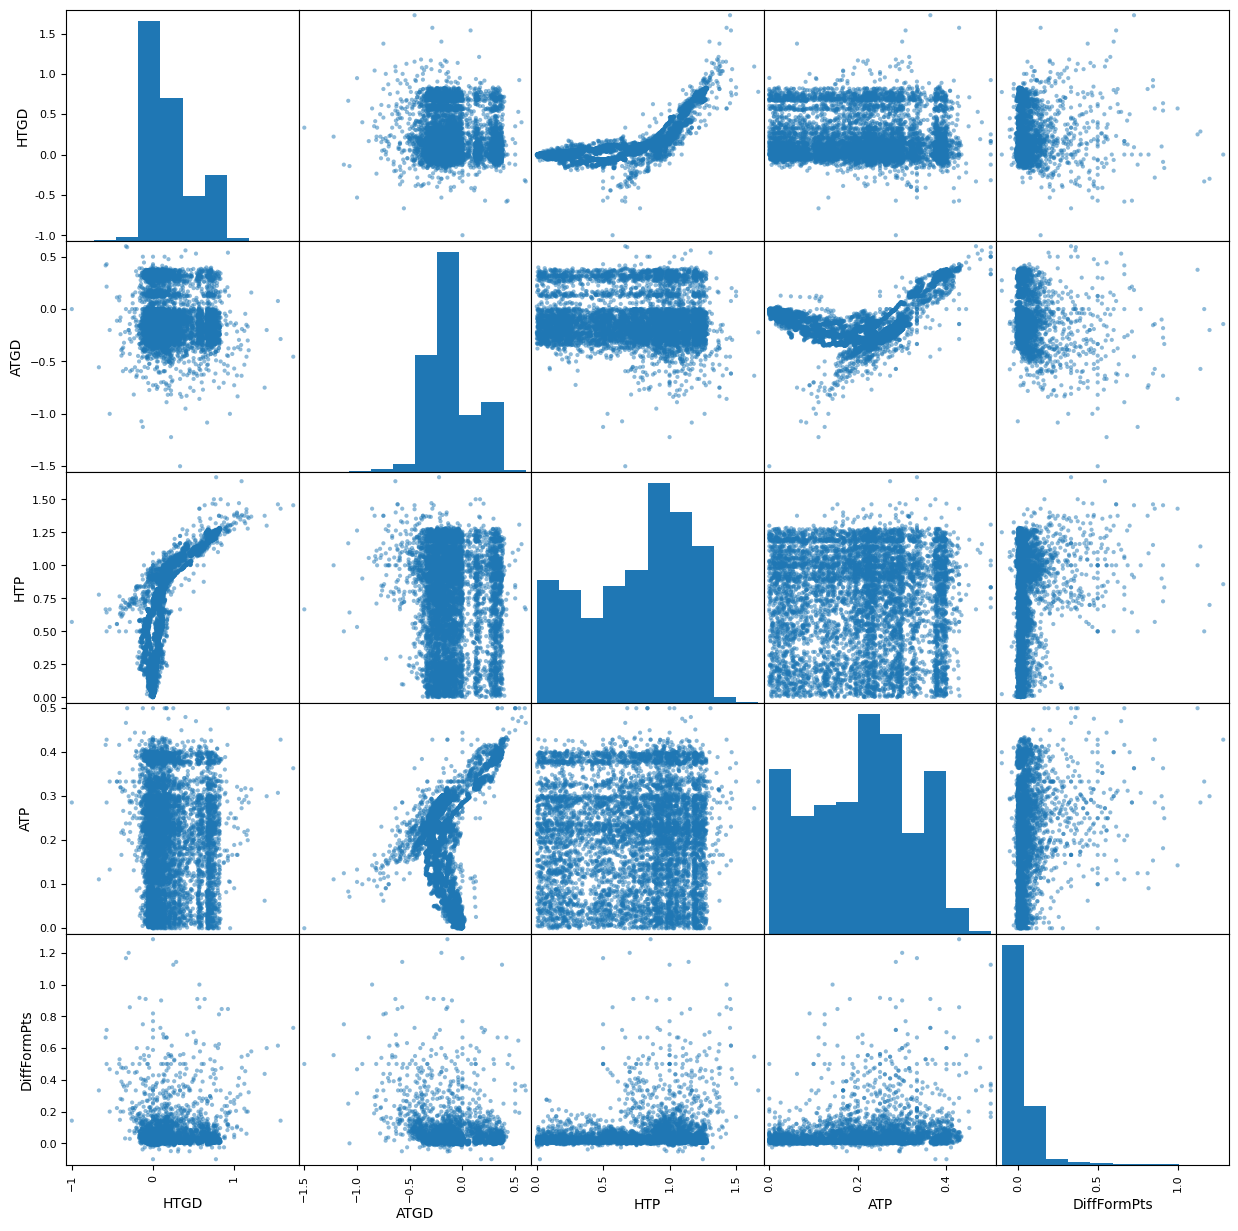

In [25]:
# Visualising distribution of data
from pandas.plotting import scatter_matrix

#the scatter matrix is plotting each of the columns specified against each other column.
#You would have observed that the diagonal graph is defined as a histogram, which means that in the 
#section of the plot matrix where the variable is against itself, a histogram is plotted.

#Scatter plots show how much one variable is affected by another. 
#The relationship between two variables is called their correlation
#negative vs positive correlation

#HTGD - Home team goal difference
#ATGD - away team goal difference
#HTP - Home team points
#ATP - Away team points
#DiffFormPts Diff in points
#DiffLP - Differnece in last years prediction

scatter_matrix(dataset2[['HTGD','ATGD','HTP','ATP','DiffFormPts']], figsize=(15,15))

In [26]:
# ONLY USE 5 FEATURES

features = ['HTGS', 'ATGS', 'HTGD', 'ATGD', 'DiffPts']

X = df[features]

y = df['FTR']

In [27]:
# FEATURES AND TARGET

#X = df.drop("FTR", axis=1)

#y = df["FTR"]


# REMOVE NON-NUMERIC COLUMNS

X = X.select_dtypes(include=["number"])


# STANDARDIZE FEATURES

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


print("Feature Shape:", X_scaled.shape)

print("Target Shape:", y.shape)

Feature Shape: (7170, 5)
Target Shape: (7170,)


In [28]:
df.head(10)

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTGS,ATGS,HTGC,ATGC,...,HTLossStreak3,HTLossStreak5,ATWinStreak3,ATWinStreak5,ATLossStreak3,ATLossStreak5,HTGD,ATGD,DiffPts,DiffFormPts
50,16/09/00,Aston Villa,Bradford,2,0,H,9,5,4,4,...,0,0,0,0,0,0,0.833333,0.166667,1.166667,0.166667
51,16/09/00,Charlton,Tottenham,1,0,H,3,0,1,9,...,0,0,0,0,0,0,0.333333,-1.500000,0.666667,0.500000
52,16/09/00,Everton,Man United,1,3,NH,6,1,1,4,...,0,0,0,0,0,0,0.833333,-0.500000,1.000000,0.333333
53,16/09/00,Leeds,Ipswich,1,2,NH,6,6,5,4,...,0,0,0,0,0,0,0.166667,0.333333,0.333333,0.666667
54,16/09/00,Southampton,Newcastle,2,0,H,4,4,4,6,...,0,0,0,0,0,0,0.000000,-0.333333,0.666667,0.166667
55,16/09/00,Sunderland,Derby,2,1,H,6,2,5,4,...,0,0,0,0,0,0,0.166667,-0.333333,0.666667,0.500000
56,17/09/00,Chelsea,Leicester,0,2,NH,4,5,2,7,...,0,0,0,0,0,0,0.333333,-0.333333,1.000000,0.333333
57,17/09/00,Man City,Middlesbrough,1,1,NH,6,3,6,0,...,0,0,0,0,0,0,0.000000,0.500000,0.333333,0.333333
58,17/09/00,West Ham,Liverpool,1,1,NH,6,7,5,5,...,0,0,0,0,0,0,0.166667,0.333333,0.333333,0.166667
59,23/09/00,Bradford,Southampton,0,1,NH,3,4,4,6,...,0,0,0,0,0,0,-0.166667,-0.333333,0.166667,0.500000


## Spliting the dataset

In [29]:
from sklearn.model_selection import train_test_split

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# SHAPES

print("X_train:", X_train.shape)

print("X_test :", X_test.shape)

print("y_train:", y_train.shape)

print("y_test :", y_test.shape)

X_train: (5019, 5)
X_test : (2151, 5)
y_train: (5019,)
y_test : (2151,)


# Applying the Logistic Regression

In [30]:
# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [31]:
Y_pred = classifier.predict(X_test)

In [32]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, Y_pred)

<Axes: >

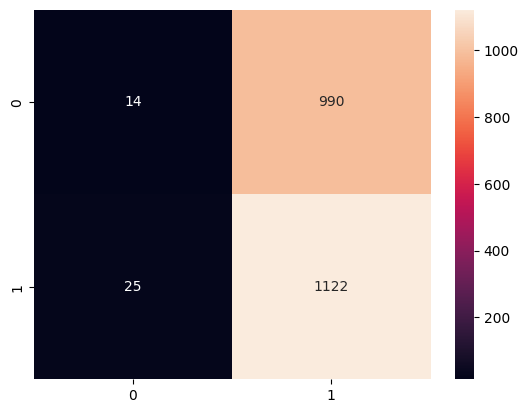

In [33]:
sns.heatmap(cm, annot=True,fmt='d')

In [34]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.36      0.01      0.03      1004
          NH       0.53      0.98      0.69      1147

    accuracy                           0.53      2151
   macro avg       0.45      0.50      0.36      2151
weighted avg       0.45      0.53      0.38      2151



# Applying the SVM

In [35]:
#fitting the SVM to the training set
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf',random_state = 0)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
#predicting result
Y_pred = classifier.predict(X_test)

In [37]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, Y_pred)

<Axes: >

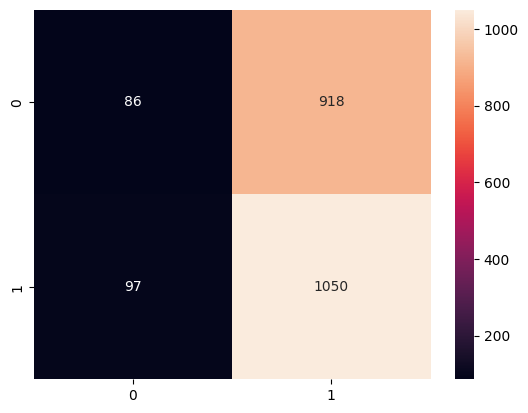

In [38]:
sns.heatmap(cm, annot=True, fmt='d')

In [39]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.47      0.09      0.14      1004
          NH       0.53      0.92      0.67      1147

    accuracy                           0.53      2151
   macro avg       0.50      0.50      0.41      2151
weighted avg       0.50      0.53      0.43      2151



# Applying the RandomForest

In [40]:
# FITTING RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    criterion='gini',
    n_estimators=700,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='sqrt',   # FIXED
    oob_score=True,
    random_state=1,
    n_jobs=-1
)

classifier.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [41]:
#predicting result
Y_pred = classifier.predict(X_test)


In [42]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, Y_pred)

<Axes: >

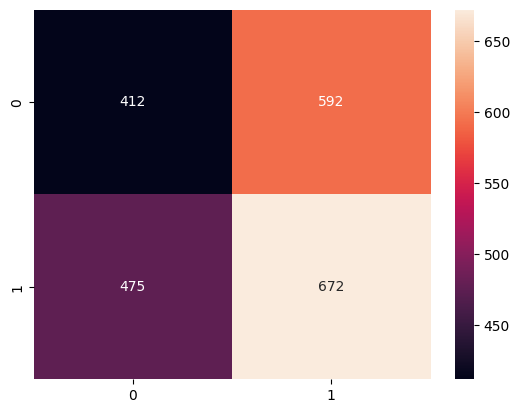

In [43]:
sns.heatmap(cm, annot=True, fmt='d')

In [44]:
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           H       0.46      0.41      0.44      1004
          NH       0.53      0.59      0.56      1147

    accuracy                           0.50      2151
   macro avg       0.50      0.50      0.50      2151
weighted avg       0.50      0.50      0.50      2151



# Applying the XGBoost

In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

In [46]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# FITTING XGBOOST

from xgboost import XGBClassifier

classifier = XGBClassifier(
    random_state=82,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

classifier.fit(X_train, y_train_encoded)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [48]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)

In [49]:
# Making the Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[349 655]
 [324 823]]


<Axes: >

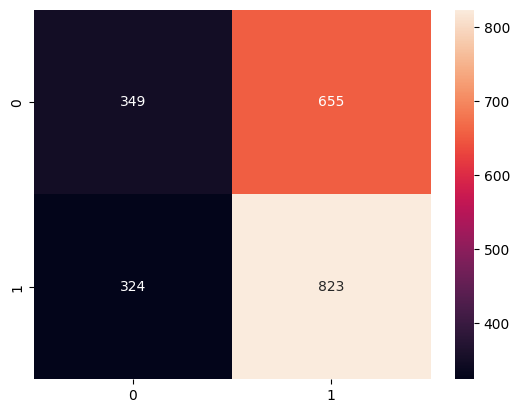

In [50]:
sns.heatmap(cm, annot=True,fmt='d')

In [51]:
from sklearn.metrics import classification_report

y_pred = classifier.predict(X_test)

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.35      0.42      1004
           1       0.56      0.72      0.63      1147

    accuracy                           0.54      2151
   macro avg       0.54      0.53      0.52      2151
weighted avg       0.54      0.54      0.53      2151



**Clearly XGBoost seems like the best model as it has the highest F1 score and accuracy score on the test set.**

# Tuning the parameters of XGBoost.


In [52]:
# GRID SEARCH WITH XGBOOST

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb


# ENCODE LABELS
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


# PARAMETERS
parameters = {
    'learning_rate': [0.1],
    'n_estimators': [40],
    'max_depth': [3],
    'min_child_weight': [3],
    'gamma': [0.4],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [1],
    'reg_alpha': [1e-5]
}


# PREDICTION FUNCTION
def predict_labels(clf, features, target):

    y_pred = clf.predict(features)

    return (
        f1_score(target, y_pred),
        sum(target == y_pred) / float(len(y_pred))
    )


# INITIALIZE MODEL
clf = xgb.XGBClassifier(
    random_state=2,
    eval_metric='logloss'
)


# F1 SCORER
f1_scorer = make_scorer(f1_score)


# GRID SEARCH
grid_obj = GridSearchCV(
    clf,
    scoring=f1_scorer,
    param_grid=parameters,
    cv=5
)


# TRAIN
grid_obj.fit(X_train, y_train_encoded)


# BEST MODEL
clf = grid_obj.best_estimator_

print(clf)


# TRAINING SCORE
f1, acc = predict_labels(clf, X_train, y_train_encoded)

print("Training F1 Score:", round(f1, 4))
print("Training Accuracy:", round(acc, 4))


# TEST SCORE
f1, acc = predict_labels(clf, X_test, y_test_encoded)

print("Test F1 Score:", round(f1, 4))
print("Test Accuracy:", round(acc, 4))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.4,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=40, n_jobs=None,
              num_parallel_tree=None, ...)
Training F1 Score: 0.7005
Training Accuracy: 0.5844
Test F1 Score: 0.6602
Test Accuracy: 0.5277


#### Probably little best!!!!!!!!

Accuracy is not soo good but it can improved.

Actually it only depend upon past year match dataset,we can improve the accuracy by putting twitter data related to match, sentiment analysis, chances of player to play a specific match,player performace in recent series,etc..

I hope you find this kernel useful and enjoyable. If so please upVote

Your comments and feedback are most welcome.

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced"
    ))
])

model.fit(X, y)
joblib.dump(model, "football_model.pkl")

['football_model.pkl']

In [54]:
print(X.columns)

Index(['HTGS', 'ATGS', 'HTGD', 'ATGD', 'DiffPts'], dtype='object')
